#NLPstudy_02 - 한국어 감성 분석 챗봇(BeamSearch)
- 데이터셋: Chatbot_data_for_Korean v1.0 (11,876 문답 쌍)
- Decoding 방법 : BeamSearch (각 step마다 상위 k개의 후보 문장만 유지하면서 확률이 가장 높은 경로를 탐색)
- 기술 : Python ,TensorFlow ,SentencePiece ,NLTK BLEU

---

# 0. 패키지 설치 및 import

In [ ]:
!pip install -q sentencepiece
!pip install -q nltk

import nltk
nltk.download('punkt', quiet=True)

True

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import json

import tensorflow as tf
import sentencepiece as spm

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

print('TensorFlow:', tf.__version__)
print('GPU:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.19.0
GPU: True


#1. 하이퍼 파라미터 설정

In [ ]:
LATENT_DIM    = 256 # 수정
EMBEDDING_DIM = 128 # 수정
VOCAB_SIZE    = 5000
MAX_LEN       = 30
BATCH_SIZE    = 64
EPOCHS        = 100

PAD_ID = 0; BOS_ID = 1; EOS_ID = 2; UNK_ID = 3

#2. 데이터 로드/ 분포

In [ ]:
df = pd.read_csv(
    'https://raw.github.com/ironmanciti/Infran_NLP/master/data/ChatbotData.csv'
)
print('shape:', df.shape)
print(df.head())
# 컬럼: Q (질문) / A (답변) / label (감정 0~2)

shape: (11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


감정 레이블 분포:
label
0    5290
1    3570
2    2963
Name: count, dtype: int64
              Q_len         A_len
count  11823.000000  11823.000000
mean      12.879049     15.015140
std        6.167467      6.701835
min        1.000000      1.000000
25%        9.000000     10.000000
50%       12.000000     14.000000
75%       16.000000     18.000000
max       56.000000     76.000000


/tmp/ipykernel_3857/4275405268.py:11: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3857/4275405268.py:11: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3857/4275405268.py:11: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3857/4275405268.py:11: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3857/4275405268.py:11: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3857/4275405268.py:11: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.

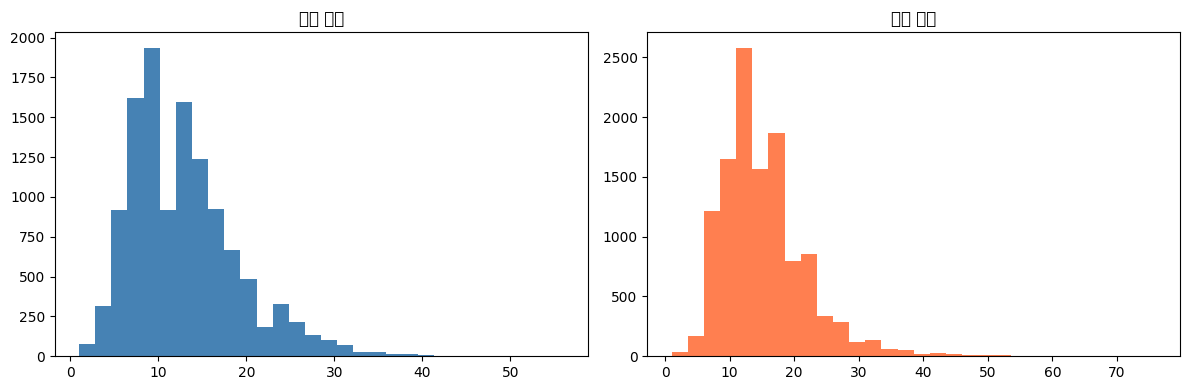

In [ ]:
print('감정 레이블 분포:')
print(df['label'].value_counts())

df['Q_len'] = df['Q'].apply(len)
df['A_len'] = df['A'].apply(len)
print(df[['Q_len', 'A_len']].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1); plt.hist(df['Q_len'], bins=30, color='steelblue'); plt.title('질문 길이')
plt.subplot(1,2,2); plt.hist(df['A_len'], bins=30, color='coral');     plt.title('답변 길이')
plt.tight_layout(); plt.show()

#3. Q/A 리스트 생성

In [ ]:
Q_texts   = df['Q'].tolist()
A_texts   = df['A'].tolist()
All_texts = Q_texts + A_texts
print(f'Q: {len(Q_texts)}개, A: {len(A_texts)}개')

Q: 11823개, A: 11823개


#4. SentencePiece 학습

In [ ]:
with open('chatbot_qna.txt', 'w', encoding='utf-8') as f:
    for line in All_texts:
        f.write(line + '\n')

In [ ]:
cmd = (
    f'--input=chatbot_qna.txt '
    f'--model_prefix=chatbot_spm '
    f'--vocab_size={VOCAB_SIZE} '
    f'--pad_id={PAD_ID} '
    f'--bos_id={BOS_ID} '
    f'--eos_id={EOS_ID} '
    f'--unk_id={UNK_ID}'
)
spm.SentencePieceTrainer.Train(cmd)
print('학습 완료!')

학습 완료!


#5. 토크나이저 로드

In [ ]:
sp_model = spm.SentencePieceProcessor()
sp_model.Load('chatbot_spm.model')

test = '오늘 날씨가 너무 좋아서 기분이 최고야'
print('원문:', test)
print('토큰:', sp_model.encode_as_pieces(test))
print('ID: ',  sp_model.encode_as_ids(test))

원문: 오늘 날씨가 너무 좋아서 기분이 최고야
토큰: ['▁오늘', '▁날씨', '가', '▁너무', '▁좋아', '서', '▁기분이', '▁최고', '야']
ID:  [78, 606, 7, 22, 118, 25, 620, 1348, 81]


#6. 시퀀스 생성

In [ ]:
sp_model.SetEncodeExtraOptions('')
Q_sequences = [sp_model.encode_as_ids(s) for s in Q_texts]

sp_model.SetEncodeExtraOptions('bos:')
A_sequences_inputs = [sp_model.encode_as_ids(s) for s in A_texts]

sp_model.SetEncodeExtraOptions(':eos')
A_sequences_targets = [sp_model.encode_as_ids(s) for s in A_texts]

print('Q 예시:', Q_sequences[0])
print('A입력 :', A_sequences_inputs[0])
print('A목표 :', A_sequences_targets[0])

Q 예시: [4228, 299, 5, 4826, 72]
A입력 : [1, 282, 7, 113, 82, 23, 4]
A목표 : [282, 7, 113, 82, 23, 4, 2]


#7. 패딩
- Encoder: pre 패딩 (앞쪽 0) → Thought Vector 품질 향상
- Decoder: post 패딩 (뒤쪽 0) → Teacher Forcing 올바르게 동작

In [ ]:
encoder_inputs  = pad_sequences(Q_sequences,         maxlen=MAX_LEN)
decoder_inputs  = pad_sequences(A_sequences_inputs,  maxlen=MAX_LEN, padding='post')
decoder_targets = pad_sequences(A_sequences_targets, maxlen=MAX_LEN, padding='post')

print('Encoder input shape:', encoder_inputs.shape)
print('Decoder input shape:', decoder_inputs.shape)
print('Decoder target shape:', decoder_targets.shape)

Encoder input shape: (11823, 30)
Decoder input shape: (11823, 30)
Decoder target shape: (11823, 30)


# 8. 학습용 모델 구성

In [ ]:
# Encoder 구성
encoder_inputs_ = Input(shape=(MAX_LEN,), name='Encoder_Input')
embedding_encoder = Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM)
x = embedding_encoder(encoder_inputs_)
encoder_outputs, h, c = LSTM(LATENT_DIM, return_state=True, name='Encoder_LSTM')(x)
encoder_states = [h, c]

encoder_model = Model(encoder_inputs_, encoder_states, name='Encoder_Model')


#  Decoder 구성 (Teacher Forcing용)
decoder_inputs_ = Input(shape=(MAX_LEN,), name='Decoder_Input')
embedding_decoder = Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM)
x = embedding_decoder(decoder_inputs_)

decoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True, name='Decoder_LSTM')
decoder_out, _, _ = decoder_lstm(x, initial_state=encoder_states)

decoder_dense = Dense(VOCAB_SIZE + 1, activation='softmax', name='Output_Dense')
decoder_outputs = decoder_dense(decoder_out)

model_teacher_forcing = Model(
    [encoder_inputs_, decoder_inputs_],
    decoder_outputs,
    name='Seq2Seq_Train'
)
model_teacher_forcing.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_teacher_forcing.summary()

Model: "Seq2Seq_Train"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 128)   │    640,128 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 30, 128)   │    640,128 │ Decoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_LSTM (LSTM) │ [(None, 256),     │    394,240 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM (LSTM) │ [(None, 30, 256), │    394,240 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ Encoder_LSTM[0][… │
│                     │ (None, 256)]      │            │ Encoder_LSTM[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Dense        │ (None, 30, 5001)  │  1,285,257 │ Decoder_LSTM[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,353,993 (12.79 MB)

 Trainable params: 3,353,993 (12.79 MB)

 Non-trainable params: 0 (0.00 B)

#9. 추론용 Decorder 분리

In [ ]:
decoder_state_input_h = Input(shape=(LATENT_DIM,), name='Dec_h')
decoder_state_input_c = Input(shape=(LATENT_DIM,), name='Dec_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
decoder_inputs_single = Input(shape=(1,), name='Dec_Single_Input')

x = embedding_decoder(decoder_inputs_single)
dec_out, h_out, c_out = decoder_lstm(x, initial_state=decoder_states_inputs)
dec_out = decoder_dense(dec_out)

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [dec_out, h_out, c_out],
    name='Decoder_Inference'
)


#10. 학습 / 저장

In [ ]:
# 학습 및 저장
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1)
]

history = model_teacher_forcing.fit(
    [encoder_inputs, decoder_inputs],
    decoder_targets,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.7604 - loss: 2.0329 - val_accuracy: 0.7675 - val_loss: 1.6938
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.7976 - loss: 1.4255 - val_accuracy: 0.7718 - val_loss: 1.5949
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8013 - loss: 1.3527 - val_accuracy: 0.7757 - val_loss: 1.5499
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8056 - loss: 1.3066 - val_accuracy: 0.7819 - val_loss: 1.5174
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8089 - loss: 1.2660 - val_accuracy: 0.7845 - val_loss: 1.4893
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8124 - loss: 1.2278 - val_accuracy: 0.7877 - val_loss: 1.4674
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8160 - loss: 1.1904 - val_accuracy: 0.7910 - val_loss: 1.4453
Epoch 8/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8200 - loss: 1.1517 -

/tmp/ipykernel_3857/823171147.py:15: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3857/823171147.py:15: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3857/823171147.py:15: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3857/823171147.py:15: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3857/823171147.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig('beam_learning_curve.png', dpi=150)
/tmp/ipykernel_3857/823171147.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.savefig('beam_learning_curve.png', dpi=150)
/tmp/ipykernel_3857/823171147.py:16: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE

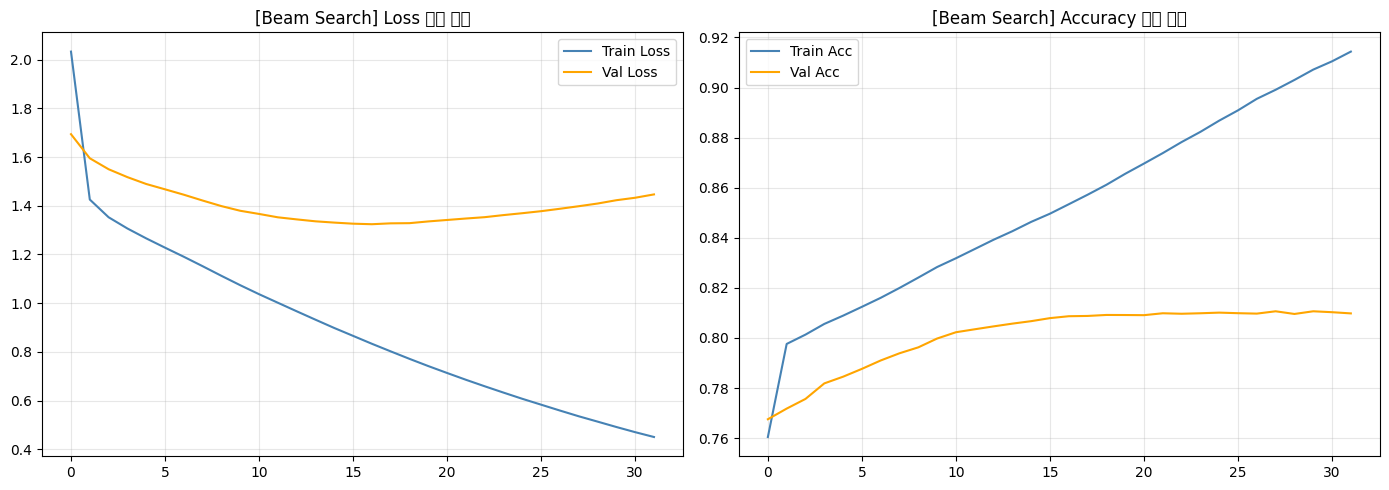

저장 완료: beam_learning_curve.png


In [ ]:
# 학습 곡선 시각화

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('[Beam Search] Loss 학습 곡선')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
axes[1].set_title('[Beam Search] Accuracy 학습 곡선')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('beam_learning_curve.png', dpi=150)
plt.show()
print('저장 완료: beam_learning_curve.png')

model_teacher_forcing.save('chatbot_seq2seq_beam.h5')

#11. BeamSearch decode_sequence

In [ ]:
def decode_beam(input_seq, beam_width=3):
    """Beam Search 전략: 상위 beam_width개 후보 유지"""
    start = time.time()

    # 1) Thought Vector 추출
    states = encoder_model.predict(input_seq, verbose=0)
    h_init, c_init = states[0], states[1]

    # 2) 초기 beam: (누적 log 확률, 생성된 토큰 리스트, [h, c])
    beams     = [(0.0, [], [h_init, c_init])]
    completed = []

    for _ in range(MAX_LEN):
        new_beams = []

        for log_prob, tokens, states_b in beams:
            # 이미 완료된 beam은 건너뜀
            if tokens and tokens[-1] == EOS_ID:
                completed.append((log_prob, tokens))
                continue

            last_token = tokens[-1] if tokens else BOS_ID
            target_seq = np.array([[last_token]])

            output, h, c = decoder_model.predict(
                [target_seq] + states_b, verbose=0
            )
            probs = output[0, -1, :]

            # 수정
            probs = probs.copy()
            probs[UNK_ID] = 0  # UNK 토큰 제거

            # 상위 beam_width개 토큰 후보 선택
            top_ids = np.argsort(probs)[::-1][:beam_width]

            for token_id in top_ids:
                new_log_prob = log_prob + np.log(probs[token_id] + 1e-10)
                new_tokens   = tokens + [int(token_id)]
                new_beams.append((new_log_prob, new_tokens, [h, c]))

        if not new_beams:
            break

        # 누적 확률 기준 상위 beam_width개만 유지
        beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_width]

        # 모든 beam이 EOS에 도달하면 종료
        if all(b[1] and b[1][-1] == EOS_ID for b in beams):
            break

    completed += [(lp, toks) for lp, toks, _ in beams]
    best_log_prob, best_tokens = max(completed, key=lambda x: x[0])

    # EOS 제거
    result  = [t for t in best_tokens if t != EOS_ID]
    elapsed = (time.time() - start) * 1000
    return result, elapsed


def chat_beam(question, beam_width=3):
    sp_model.SetEncodeExtraOptions('')
    seq = sp_model.encode_as_ids(question)
    enc_input = pad_sequences([seq], maxlen=MAX_LEN)

    token_ids, ms = decode_beam(enc_input, beam_width=beam_width)
    response = sp_model.DecodeIds(token_ids)
    return response, ms

# 12. width 별 대화 응답 테스트

In [ ]:
test_questions = [
    '오늘 너무 힘들었어',
    '취업 준비가 너무 막막해',
    '친한 친구랑 크게 싸웠어',
    '좋아하는 사람이 생겼어',
    '요즘 잠을 못 자겠어',
]

beam_widths  = [3, 5, 7, 10]
response_log = {f'Beam-{bw}': [] for bw in beam_widths}

for bw in beam_widths:
    print(f'\n{"="*55}')
    print(f'Beam Width = {bw}')
    print(f'{"="*55}')
    print(f"{'질문':20s} | {'응답':25s} | {'시간':>8s}")
    print('-' * 55)
    for q in test_questions:
        ans, ms = chat_beam(q, beam_width=bw)
        response_log[f'Beam-{bw}'].append({'질문': q, '응답': ans, '시간(ms)': round(ms, 1)})
        print(f'{q:20s} | {ans:25s} | {ms:>6.1f}ms')


Beam Width = 3
질문                   | 응답                        |       시간
-------------------------------------------------------
오늘 너무 힘들었어           | 감기 조심하세요.                 | 7226.2ms
취업 준비가 너무 막막해        | 많이 지쳤나봐요.                 | 2802.6ms
친한 친구랑 크게 싸웠어        | 저랑 놀아요.                   | 3210.8ms
좋아하는 사람이 생겼어         | 많이 지쳤나봐요.                 | 7168.5ms
요즘 잠을 못 자겠어          | 항상 마음을 가져보세요.             | 6575.2ms

Beam Width = 5
질문                   | 응답                        |       시간
-------------------------------------------------------
오늘 너무 힘들었어           | 감기 조심하세요.                 | 11410.1ms
취업 준비가 너무 막막해        | 많이 지쳤나봐요.                 | 11643.4ms
친한 친구랑 크게 싸웠어        | 저랑 놀아요.                   | 11355.5ms
좋아하는 사람이 생겼어         | 많이 지쳤나봐요.                 | 12064.4ms
요즘 잠을 못 자겠어          | 잘 될 거예요.                  | 12478.2ms

Beam Width = 7
질문                   | 응답                        |       시간
-------------------------------------------------------

#13.BLUE Score (width별)

In [ ]:
## 샘플 수 절반으로 줄이기..?

def compute_bleu_beam(beam_width, n_samples=100):  # 수정 : 200-> 100
    references, hypotheses = [], []
    sp_model.SetEncodeExtraOptions('')

    for i in range(n_samples):
        seq       = sp_model.encode_as_ids(Q_texts[i])
        enc_input = pad_sequences([seq], maxlen=MAX_LEN)
        token_ids, _ = decode_beam(enc_input, beam_width=beam_width)

        ref_ids = sp_model.encode_as_ids(A_texts[i])
        references.append([ref_ids])
        hypotheses.append(token_ids)

    smoother = SmoothingFunction().method1
    return corpus_bleu(references, hypotheses, smoothing_function=smoother)

beam_bleu = {}
for bw in beam_widths:
    print(f'Beam-{bw} BLEU 계산 중...')
    beam_bleu[f'Beam-{bw}'] = compute_bleu_beam(bw)
    print(f'  → BLEU: {beam_bleu[f"Beam-{bw}"]:.4f}')

print('\n=== BLEU Score 비교 결과 ===')
for k, v in beam_bleu.items():
    bar = '█' * int(v * 100)
    print(f'{k:12s}: {v:.4f} {bar}')

Beam-7 BLEU 계산 중...
  → BLEU: 0.0363
Beam-10 BLEU 계산 중...
  → BLEU: 0.0276

=== BLEU Score 비교 결과 ===
Beam-7      : 0.0363 ███
Beam-10     : 0.0276 ██


#14. 응답 속도 측정(10회 평균)

In [ ]:
# 속도 측정
print('\n응답 속도 측정 중...')

sp_model.SetEncodeExtraOptions('')
seq       = sp_model.encode_as_ids('오늘 기분이 좀 이상해')
enc_input = pad_sequences([seq], maxlen=MAX_LEN)

beam_speed = {}
for bw in beam_widths:
    times = [decode_beam(enc_input, beam_width=bw)[1] for _ in range(10)]
    beam_speed[f'Beam-{bw}'] = round(np.mean(times), 1)
    print(f'Beam-{bw} 평균 응답 시간: {np.mean(times):.1f}ms')



응답 속도 측정 중...
Beam-7 평균 응답 시간: 15828.5ms


KeyboardInterrupt: 

/tmp/ipykernel_4219/3697168050.py:14: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4219/3697168050.py:14: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4219/3697168050.py:14: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4219/3697168050.py:14: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4219/3697168050.py:14: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4219/3697168050.py:14: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4219/3697168050.py:14: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_

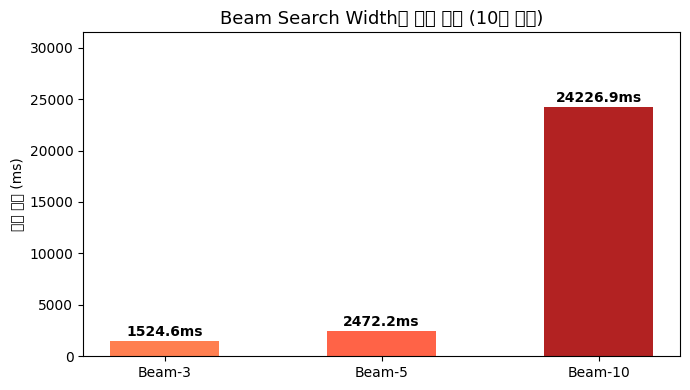

저장 완료: beam_speed.png


In [ ]:
# 속도 그래프

labels = list(beam_speed.keys())
speeds = list(beam_speed.values())

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, speeds, color=['coral', 'tomato', 'firebrick'], width=0.5)
plt.title('Beam Search Width별 응답 속도 (10회 평균)', fontsize=13)
plt.ylabel('응답 시간 (ms)')
plt.ylim(0, max(speeds) * 1.3)
for bar, spd in zip(bars, speeds):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(speeds)*0.02,
             f'{spd:.1f}ms', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('beam_speed.png', dpi=150)
plt.show()
print('저장 완료: beam_speed.png')


# 15. Beam width 별 BLUE 추이 그래프

In [ ]:
widths     = [int(k.split('-')[1]) for k in beam_bleu.keys()]
bleu_vals  = list(beam_bleu.values())

plt.figure(figsize=(7, 4))
plt.plot(widths, bleu_vals, marker='o', color='steelblue', linewidth=2, markersize=8)
for x, y in zip(widths, bleu_vals):
    plt.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=10)
plt.title('Beam Width에 따른 BLEU Score 변화', fontsize=13)
plt.xlabel('Beam Width')
plt.ylabel('BLEU Score')
plt.xticks(widths)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('beam_bleu_trend.png', dpi=150)
plt.show()
print('저장 완료: beam_bleu_trend.png')

#16. 정성 평가

In [ ]:
# 실험 결과를 직접 보고 점수 수정 (5점 척도)
qualitative = {
    'Beam-3' : {'자연스러움': 2, '다양성': 3, '일관성': 2},
    'Beam-5' : {'자연스러움': 2, '다양성': 2, '일관성': 2},
    'Beam-7' : {'자연스러움': 3, '다양성': 2, '일관성': 2},
    'Beam-10': {'자연스러움': 3, '다양성': 3, '일관성': 2},
}

print('=== 정성 평가 (Beam Search) ===')
for strategy, scores in qualitative.items():
    print(f'\n  [{strategy}]')
    for k, v in scores.items():
        bar = '★' * v + '☆' * (5 - v)
        print(f'    {k}: {bar} ({v}/5)')

=== 정성 평가 (Beam Search) ===

  [Beam-3]
    자연스러움: ★★☆☆☆ (2/5)
    다양성: ★★★☆☆ (3/5)
    일관성: ★★☆☆☆ (2/5)

  [Beam-5]
    자연스러움: ★★☆☆☆ (2/5)
    다양성: ★★☆☆☆ (2/5)
    일관성: ★★☆☆☆ (2/5)

  [Beam-10]
    자연스러움: ★★★☆☆ (3/5)
    다양성: ★★★☆☆ (3/5)
    일관성: ★★☆☆☆ (2/5)


#17. 결과 저장

In [ ]:
beam_results = {
    'bleu'        : beam_bleu,
    'avg_ms'      : beam_speed,
    'qualitative' : qualitative,
    'responses'   : response_log,
}

with open('beam_results.json', 'w', encoding='utf-8') as f:
    json.dump(beam_results, f, ensure_ascii=False, indent=2)

print('\n=== Beam Search 실험 완료 ===')
for bw in beam_widths:
    k = f'Beam-{bw}'
    print(f'{k}: BLEU={beam_bleu[k]:.4f}, 속도={beam_speed[k]:.1f}ms')
print('결과 저장  : beam_results.json')
print('그래프 저장: beam_learning_curve.png, beam_speed.png, beam_bleu_trend.png')